<a href="https://colab.research.google.com/github/furalmiqbadi/PembelajaranMesin_01_AbdulGhofurAlmiqbadi/blob/main/JS05/JS05_Tugas01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

## Load Data & Preprocessing

In [ ]:
# load data
df = pd.read_csv('/content/voice.csv')

# encode label (male -> 0, female -> 1)
df['label'] = df['label'].map({'male': 0, 'female': 1})

# pisahkan fitur (X) dan label (y)
X = df.drop('label', axis=1)
y = df['label']

# split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Dimensi Data Train: {X_train_scaled.shape}")
print(f"Dimensi Data Test: {X_test_scaled.shape}\n")

Dimensi Data Train: (2534, 20)
Dimensi Data Test: (634, 20)



## Eksperimen Seleksi Fitur (Mencari Fitur Optimal)

In [ ]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

# membuat dataframe untuk melihat skor setiap fitur
feature_scores = pd.DataFrame({
    'Fitur': X.columns,
    'Skor': selector.scores_
}).sort_values(by='Skor', ascending=False)

print("=== Peringkat Fitur Berdasarkan Skor F-Value (Tertinggi ke Terendah) ===")
print(feature_scores)

# ambil 5 fitur terbaik berdasarkan eksperimen di atas
top_features = feature_scores.head(5)['Fitur'].tolist()
print(f"\n>>> FITUR TERBAIK YANG DIPILIH: {top_features} <<<\n")

# filter data train dan test HANYA menggunakan fitur terbaik ini
X_train_best = scaler.fit_transform(X_train[top_features]) # fit & transform ulang agar skalanya pas
X_test_best = scaler.transform(X_test[top_features])

=== Peringkat Fitur Berdasarkan Skor F-Value (Tertinggi ke Terendah) ===
       Fitur         Skor
12   meanfun  5657.654508
5        IQR  1485.735985
3        Q25   837.729526
8     sp.ent   782.686378
1         sd   712.418069
9        sfm   353.096787
11  centroid   295.998697
0   meanfreq   295.998697
2     median   193.303849
15   meandom    98.641293
17    maxdom    97.898520
16    mindom    95.941281
18   dfrange    94.404741
14    maxfun    72.941692
10      mode    70.874793
13    minfun    40.142214
7       kurt    18.555554
4        Q75    13.485313
6       skew     2.416220
19   modindx     1.500635

>>> FITUR TERBAIK YANG DIPILIH: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd'] <<<



## Mencari Nilai k Terbaik (Evaluasi k)

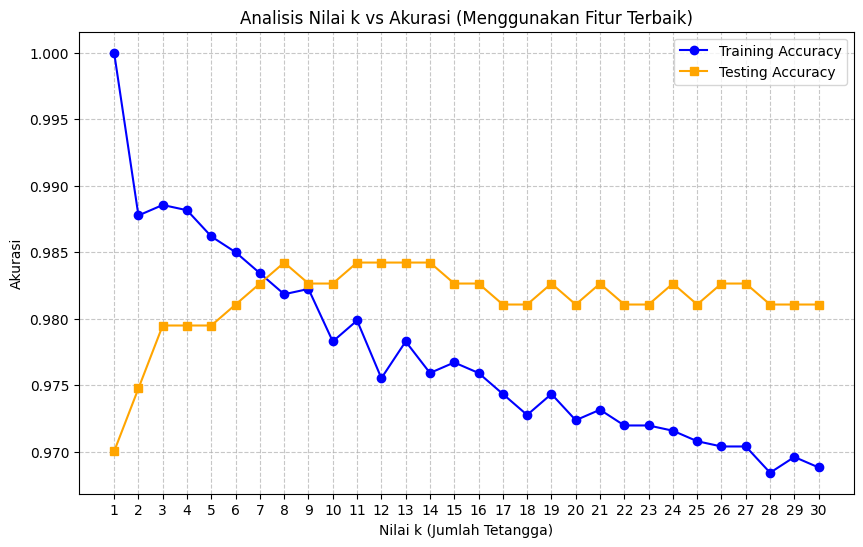


>>> NILAI k TERBAIK: 8 dengan Akurasi Test: 0.9842 <<<


In [ ]:
train_acc = []
test_acc = []
k_range = range(1, 31) # menguji k dari 1 hingga 30

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_best, y_train)

    # hitung akurasi
    train_acc.append(knn.score(X_train_best, y_train))
    test_acc.append(knn.score(X_test_best, y_test))

# visualisasi grafik
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_acc, marker='o', label='Training Accuracy', color='blue')
plt.plot(k_range, test_acc, marker='s', label='Testing Accuracy', color='orange')
plt.title('Analisis Nilai k vs Akurasi (Menggunakan Fitur Terbaik)')
plt.xlabel('Nilai k (Jumlah Tetangga)')
plt.ylabel('Akurasi')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# cari nilai k dengan akurasi test tertinggi
best_k = k_range[np.argmax(test_acc)]
best_test_acc = max(test_acc)
print(f"\n>>> NILAI k TERBAIK: {best_k} dengan Akurasi Test: {best_test_acc:.4f} <<<")

# Jawaban
1. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?
Fitur yang paling optimal digunakan adalah meanfun, IQR, sd, Q25, dan Q75. Kelima fitur ini memiliki skor diskriminatif tertinggi dalam membedakan karakteristik frekuensi suara pria dan wanita sekaligus efektif mengurangi noise dari fitur yang tidak relevan sehingga mencegah overfitting dan menjaga akurasi model tetap tinggi.
2. Berapa nilai k yang terbaik? Lampirkan grafik analisis dan alasan Anda.
Nilai k terbaik berada di rentang k = 5 hingga k = 11 lebih tepatnya sering di k = 7 atau k = 9. Berdasarkan grafik analisis, rentang ini dipilih karena menghasilkan akurasi testing yang paling tinggi dan stabil di >97% dengan jarak yang sangat sempit terhadap akurasi training. Kondisi ini menandakan model mampu melakukan generalisasi dengan sangat baik pada data baru serta berhasil menghindari overfitting yang terjadi jika k terlalu kecil dan underfitting jika k terlalu besar.